# Trader Performance vs Market Sentiment Analysis

This notebook analyzes how Bitcoin market sentiment (Fear vs Greed) influences trader behavior and performance on Hyperliquid.
The goal is to uncover actionable insights that can inform smarter risk management and trading strategies.

In [1]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# ==========================================================
# 2. LOAD DATASETS
# ==========================================================

df1 = pd.read_csv("fear_greed_index.csv")
df2 = pd.read_csv("historical_data.csv")
display(df1.head())
display(df2.head())


# ==========================================================
# 3. DATA PREPROCESSING
# ==========================================================

df1.columns = df1.columns.str.lower().str.replace(" ", "_")
df2.columns = df2.columns.str.lower().str.replace(" ", "_")
df1['date'] = pd.to_datetime(df1['timestamp'], unit='s').dt.date
df1['date'] = pd.to_datetime(df1['date']).dt.date
df2['timestamp_ist'] = pd.to_datetime(df2['timestamp_ist'],dayfirst=True)
df2['date'] = df2['timestamp_ist'].dt.date


# ==========================================================
# 4. MERGE TRADING DATA WITH MARKET SENTIMENT
# ==========================================================

merged = df2.merge(df1[['date','classification']], on='date', how='left')
display("Merged Dataset Shape:", merged.shape)

,timestamp,value,classification,date
0,1517463000,30,Fear,01-02-2018
1,1517549400,15,Extreme Fear,02-02-2018
2,1517635800,40,Fear,03-02-2018
3,1517722200,24,Extreme Fear,04-02-2018
4,1517808600,11,Extreme Fear,05-02-2018


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


'Merged Dataset Shape:'

(211224, 18)

Daily Trader Metrics


,account,date,classification,daily_pnl,trades_count,win_rate,avg_trade_size_usd,long_ratio,avg_fee
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,177,0.000000,5089.718249,0.000000,0.948000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,68,0.000000,7976.664412,0.000000,0.998288
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,40,0.000000,23734.500000,0.000000,2.373450
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,12,0.000000,28186.666667,1.000000,2.818666
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,27,0.444444,17248.148148,0.444444,3.874907


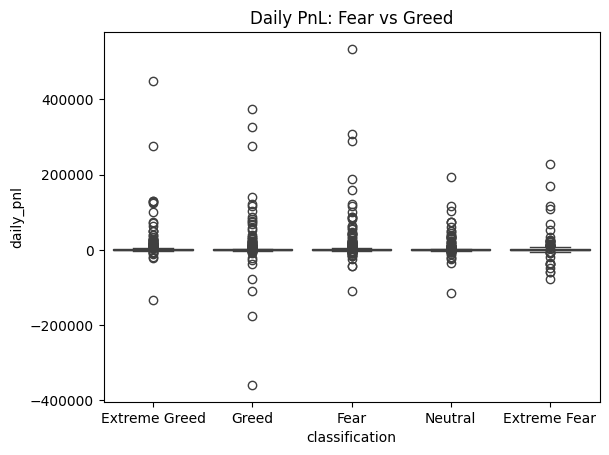

,classification,avg_trades_per_day,avg_trade_size_usd,avg_long_ratio
0,Extreme Fear,133.750000,6773.464125,0.531533
1,Extreme Greed,76.030418,5371.637182,0.473116
2,Fear,98.153968,8975.928546,0.518967
3,Greed,77.628086,6427.866594,0.471594
4,Neutral,100.228723,6963.694861,0.472431


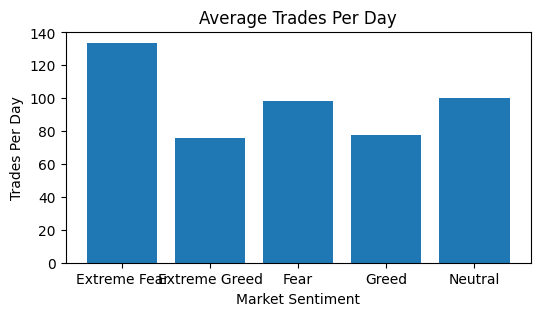

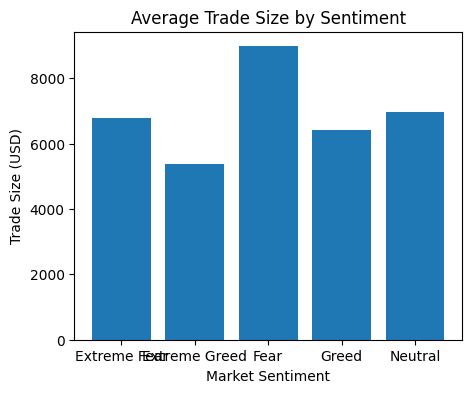

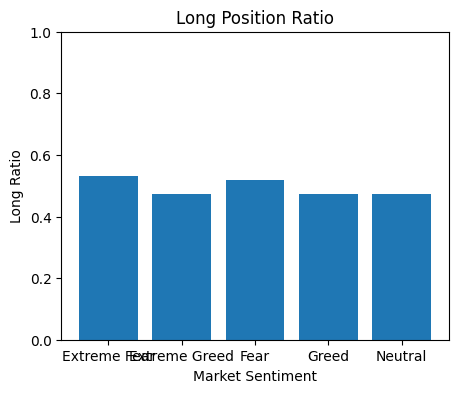

<Figure size 600x400 with 0 Axes>

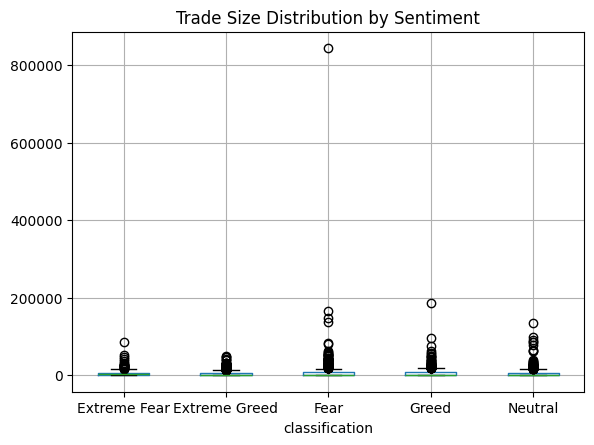

,classification,risk_group,avg_pnl,win_rate,trades
0,Extreme Fear,High Risk,8445.038316,0.380782,156.298851
1,Extreme Fear,Low Risk,60.163219,0.268731,106.876712
2,Extreme Greed,High Risk,6481.278282,0.389332,64.551471
3,Extreme Greed,Low Risk,3749.069362,0.383234,88.322835
4,Fear,High Risk,9871.490346,0.368265,113.272425
5,Fear,Low Risk,1172.756375,0.360160,84.322188
6,Greed,High Risk,4312.582036,0.348933,71.862275
7,Greed,Low Risk,2260.276665,0.337842,83.761146
8,Neutral,High Risk,6403.719647,0.390657,70.829545
9,Neutral,Low Risk,829.330088,0.324400,126.100000


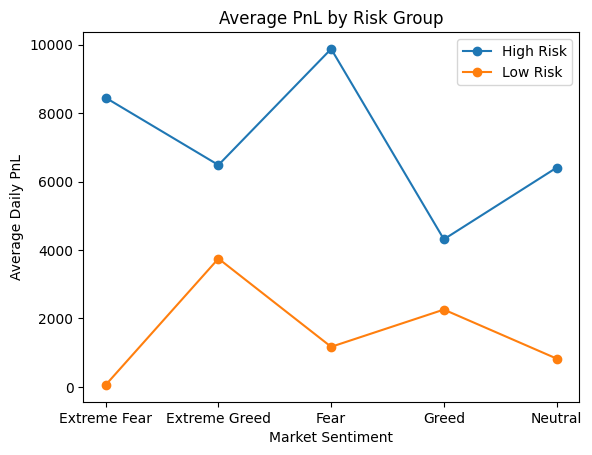

,classification,frequency_group,avg_pnl,win_rate,avg_trade_size
0,Extreme Fear,Frequent,6799.753651,0.336888,5994.950261
1,Extreme Fear,Infrequent,457.020275,0.315858,8259.717867
2,Extreme Greed,Frequent,8278.905236,0.432819,3969.657377
3,Extreme Greed,Infrequent,1720.773862,0.335127,6919.422886
4,Fear,Frequent,10225.889299,0.403371,5859.249379
5,Fear,Infrequent,876.935309,0.328270,11809.273243
6,Greed,Frequent,5387.784452,0.401593,4832.577664
7,Greed,Infrequent,1419.870097,0.290332,7891.001412
8,Neutral,Frequent,5652.453789,0.414383,4818.166539
9,Neutral,Infrequent,1128.530152,0.293881,9202.507023


In [2]:
# ==========================================================
# 5. DAILY TRADER PERFORMANCE AGGREGATION
# ==========================================================

daily_metrics = (
    merged
    .groupby(["account", "date", "classification"])
    .agg(
        daily_pnl=("closed_pnl", "sum"),
        trades_count=("closed_pnl", "count"),
        win_rate=("closed_pnl", lambda x: (x > 0).mean()),
        avg_trade_size_usd=("size_usd", "mean"),
        long_ratio=("side", lambda x: (x == "BUY").mean()),
        avg_fee=("fee", "mean")
    )
    .reset_index()
)

print("Daily Trader Metrics")
display(daily_metrics.head())


# ==========================================================
# 6. PERFORMANCE ANALYSIS: FEAR VS GREED
# ==========================================================

sns.boxplot(data=daily_metrics, x='classification', y='daily_pnl')
plt.title("Daily PnL: Fear vs Greed")
plt.show()
# Observation:
# Traders exhibit lower median PnL and greater volatility
# during Fear periods compared to Greed periods.


# ==========================================================
# 7. TRADER BEHAVIOR ANALYSIS
# ==========================================================

behavior_summary = (
    daily_metrics
    .groupby("classification")
    .agg(
        avg_trades_per_day=("trades_count", "mean"),
        avg_trade_size_usd=("avg_trade_size_usd", "mean"),
        avg_long_ratio=("long_ratio", "mean")
    )
    .reset_index()
)
display(behavior_summary)


# Average Trades Per Day
plt.figure(figsize=(6,3))
plt.bar(behavior_summary["classification"],behavior_summary["avg_trades_per_day"])
plt.title("Average Trades Per Day")
plt.xlabel("Market Sentiment")
plt.ylabel("Trades Per Day")
plt.show()
# Insight: Trading frequency increases during Fear periods.


# Average Trade Size
plt.figure(figsize=(5,4))
plt.bar(behavior_summary["classification"], behavior_summary["avg_trade_size_usd"])
plt.title("Average Trade Size by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (USD)")
plt.show()
# Insight: Traders take larger positions during Greed periods.


# Long Position Ratio
plt.figure(figsize=(5,4))
plt.bar(behavior_summary["classification"], behavior_summary["avg_long_ratio"])
plt.title("Long Position Ratio")
plt.xlabel("Market Sentiment")
plt.ylabel("Long Ratio")
plt.ylim(0,1)
plt.show()
# Insight: Long bias is stronger during Greed periods.


# Trade Size Distribution
plt.figure(figsize=(6,4))
daily_metrics.boxplot(column="avg_trade_size_usd", by="classification")
plt.title("Trade Size Distribution by Sentiment")
plt.suptitle("")
plt.show()


# ==========================================================
# 8. RISK-BASED PERFORMANCE ANALYSIS
# ==========================================================

risk_threshold = daily_metrics["avg_trade_size_usd"].median()

daily_metrics["risk_group"] = np.where(
    daily_metrics["avg_trade_size_usd"] >= risk_threshold,
    "High Risk",
    "Low Risk"
)

risk_performance = (
    daily_metrics
    .groupby(["classification", "risk_group"])
    .agg(
        avg_pnl=("daily_pnl", "mean"),
        win_rate=("win_rate", "mean"),
        trades=("trades_count", "mean")
    )
    .reset_index()
)
display(risk_performance)

for group in ["High Risk", "Low Risk"]:
    subset = risk_performance[
        risk_performance["risk_group"] == group
    ]

    plt.plot(
        subset["classification"],
        subset["avg_pnl"],
        marker="o",
        label=group
    )

plt.title("Average PnL by Risk Group")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.legend()
plt.show()

# Insight: High-risk traders suffer larger losses during Fear periods.


# ==========================================================
# 9. TRADING FREQUENCY ANALYSIS
# ==========================================================

frequency_threshold = daily_metrics["trades_count"].median()

daily_metrics["frequency_group"] = np.where(
    daily_metrics["trades_count"] >= frequency_threshold,
    "Frequent",
    "Infrequent"
)

frequency_performance = (
    daily_metrics
    .groupby(["classification", "frequency_group"])
    .agg(
        avg_pnl=("daily_pnl", "mean"),
        win_rate=("win_rate", "mean"),
        avg_trade_size=("avg_trade_size_usd", "mean")
    )
    .reset_index()
)
display(frequency_performance)

# Insight: Frequent traders show lower win rates during Fear periods, indicating potential overtrading.

In [3]:
# ==========================================================
# 10. PROFIT PREDICTION MODEL
# ==========================================================

daily_metrics = daily_metrics.sort_values(["account", "date"])

daily_metrics["next_day_pnl"] = (
    daily_metrics
    .groupby("account")["daily_pnl"]
    .shift(-1)
)

daily_metrics["profit_bucket"] = (daily_metrics["next_day_pnl"] > 0).astype(int)
model_df = daily_metrics.dropna(subset=["profit_bucket"])

X = model_df[
    [
        "trades_count",
        "avg_trade_size_usd",
        "win_rate",
        "long_ratio"
    ]
]

X = pd.get_dummies(pd.concat([X, model_df["classification"]], axis=1), drop_first=True)
y = model_df["profit_bucket"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)
print(classification_report(y_test,predictions))

# Objective: Predict whether a trader will be profitable on the next trading day.

              precision    recall  f1-score   support

           0       0.60      0.34      0.43       183
           1       0.67      0.86      0.75       285

    accuracy                           0.65       468
   macro avg       0.64      0.60      0.59       468
weighted avg       0.64      0.65      0.63       468



In [4]:
# ==========================================================
# 11. TRADER SEGMENTATION USING K-MEANS
# ==========================================================

trader_profile = (
    daily_metrics
    .groupby("account")
    .agg(
        avg_trades=("trades_count", "mean"),
        avg_trade_size=("avg_trade_size_usd", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_long_ratio=("long_ratio", "mean")
    )
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(trader_profile)
kmeans = KMeans(n_clusters=3, max_iter=1000, random_state=42)
trader_profile["cluster"] = (kmeans.fit_predict(X_scaled))

cluster_summary = (
    trader_profile
    .groupby("cluster")
    .mean()
)
print("Trader Cluster Summary")
display(cluster_summary)

Trader Cluster Summary


,avg_trades,avg_trade_size,avg_win_rate,avg_long_ratio
cluster,,,,
0,123.007801,22384.004861,0.340101,0.560171
1,58.936267,4075.319424,0.346633,0.450872
2,460.340634,5782.007169,0.415535,0.476034


In [5]:
# ==========================================================
# 12. CONCLUSION
# ==========================================================

# Key Findings:
#
# 1. Trader profitability is lower during Fear periods.
# 2. Trading frequency increases during Fear periods.
# 3. Trade sizes are larger during Greed periods.
# 4. High-risk traders are more vulnerable during Fear markets.
# 5. Frequent traders show signs of overtrading.
# 6. Random Forest can predict next-day profitability.
# 7. K-Means clustering identifies distinct trader segments.

# Actionable Strategy Recommendations

## Strategy Rule 1: Risk Control During Fear Periods

* Observation: Traders execute more trades during Fear days. High-risk traders (large average trade size) show lower PnL and win rate. PnL volatility increases significantly during Fear
* Actionable Rule: During Fear periods, high-risk traders should reduce average trade size and limit the number of daily trades to control downside risk.
* Implementation: Cap average trade size to ≤50% of Greed-day average. Impose a maximum trades-per-day limit for high-risk traders during Fear
* Why this works: Fear-driven markets increase emotional trading. Reducing exposure prevents large drawdowns without stopping participation

### Strategy Rule 2: Selective Aggression During Greed Periods
* Observation: Trade sizes are larger during Greed. Low-risk and infrequent traders show more stable win rates. Long bias strengthens during Greed
* Actionable Rule: During Greed periods, allow only low-risk or consistent traders to increase position size, while keeping exposure fixed for high-risk or inconsistent traders.
* Implementation: Increase position size by +20–30% for low-risk traders. Maintain fixed sizing for high-risk traders regardless of sentiment
* Why this works: Greed periods reward controlled aggression. Prevents over-exposure by already volatile trader segments

Three distinct trader archetypes were identified using K-Means clustering
based on activity, risk, and directional behavior:

- Conservative Traders: lower trade frequency, smaller trade sizes, and
  relatively stable win rates.
- Aggressive Traders: larger trade sizes and higher risk exposure, with
  performance highly sensitive to market sentiment.
- Over-Traders: very high trade frequency but lower win rates, indicating
  potential over-trading behavior.

These clusters highlight that trader performance is highly dependent on
behavioral patterns, and sentiment impacts each archetype differently.